# Pre-compute interface-independent domainome metrics for DPAM-AI AF2 database

Adapted from https://github.com/igashov/tricomplex-design/blob/main/notebooks/database_summary.ipynb

Computes the following for each database domain:
- sequence
- cellular location
- radius of gyration

In [1]:
from pathlib import Path
from functools import partial
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas()

import os
import sys

root_dir = !git rev-parse --show-toplevel
root_dir = root_dir[0]
os.chdir(root_dir)

In [2]:
# Define absolute paths

# DPAM-AI summary csv file
dpam_info_csv = os.path.join(root_dir, 'DPAM-AI_AFDB_domainome_v6', 'DPAM_AI_AFDB_domainome_v6_domains_info.csv')

# DPAM-AI domainome .pdb files
dpam_pdb_dir = os.path.join(root_dir, 'DPAM-AI_AFDB_domainome_v6', 'pdbs')

# old domainome_info.csv file (for reference)
old_domainome_info_csv = "/work/lpdi/users/schneuing/tricomplex-design/search_lists/filtered20251016/metrics.csv"

In [ ]:
# Check the format of the old domainome_info.csv file
df_old_domainome_info = pd.read_csv(old_domainome_info_csv)

row_old = df_old_domainome_info.iloc[0]

# Remove this df from memory
del df_old_domainome_info

row_old

id                                                   A0A024RBG1-F1-dom-01_A
uniprot_accn                                                     A0A024RBG1
sequence                  [ACE]QTRTYDREGFKKRAACLCFRSEQEDEVLLVSSSRYPDQWIV...
resi                      7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,2...
num_residues                                                            141
chain_broken                                                          False
radius_of_gyration                                                13.960375
subcellular_location                                              Cytoplasm
drug_target_gene                                                        NaN
drug_target_source                                                      NaN
full_sequence             MMKFKPNQTRTYDREGFKKRAACLCFRSEQEDEVLLVSSSRYPDQW...
protein_name              Diphosphoinositol polyphosphate phosphohydrola...
gene_name                                                            NUDT4B
extracellula

In [4]:
# Check the format of DPAM-AI domain summary csv file
df_dpam_info = pd.read_csv(dpam_info_csv)

print(df_dpam_info.shape)
df_dpam_info.iloc[0]

(52513, 17)


id                                                Q8WVQ1-F1-nD1_A
uniprot_accn                                               Q8WVQ1
Domain                                                        nD1
Range                                                      86-400
ECOD_num                                                     2167
ECOD_key                                                  e1s1dA1
T-group                                                     5.1.2
DPAM_prob                                                   0.979
HH_prob                                                       1.0
DALI_zscore                                                  57.6
Hit_cov                                                     0.994
Tgroup_cov                                                  0.969
Judge                                                 good_domain
Hcount                                                          3
Scount                                                         25
offset    

___
### Step 1 - Generate **domain_seq** column for df_dpam_info

Existing `pdb_seq` column corresponds to the exact protein sequence in the DPAM-AI generated domain .pdb file.

Generate `domain_seq` column which is the sequence that should be used for experimental testing:
- If `pdb_seq` contains no gap: simply remove the first and last `X` character (for NME and ACE residues)
- If `pdb_seq` contains gaps: after removing first and last`X`, for each gap (e.g. `X---X`), do:
    - If the `gap_length` is smaller than `min_gap_size`: use uniprot sequence to fill this gap
    - If the `gap_length` is greater than or equal to `min_gap_size`: graft a GS(D) linker to the gap

Return new columns:
- `full_sequence`: full sequence for this uniprot entry
- `num_gaps`: number of gaps in this domain
- `linker_types`: comma-delimited linker types (either `uniprot` or `GS`)
- `linker_seqs`: comma-dlimited linker sequences
- `domain_seq`: protein sequence ready to use for experiment

In [6]:
# Check if pdb_seq contains any non-letter characters
non_letter_pdb_seq = df_dpam_info[df_dpam_info['pdb_seq'].str.contains(r'[^A-Z]')]

row = non_letter_pdb_seq.iloc[0]
row

id                                                Q8WVR3-F1-nD1_A
uniprot_accn                                               Q8WVR3
Domain                                                        nD1
Range                                        1-90,141-180,206-220
ECOD_num                                                  2831701
ECOD_key                                                  e7e2cK1
T-group                                                    11.1.1
DPAM_prob                                                   0.978
HH_prob                                                       0.0
DALI_zscore                                                   4.1
Hit_cov                                                     0.748
Tgroup_cov                                                  1.343
Judge                                                 good_domain
Hcount                                                          3
Scount                                                          6
offset    

In [7]:
# Import handle_gaps module and load median linker reference
sys.path.insert(0, root_dir)
from scripts.python.handle_gaps import handle_gaps_pdb_seq, parse_pdb_seq_gaps, UnlinkableGapError
from scripts.python.DPAM_domains_to_pdb import get_uniprot_entry, _get_uniprot_sequence, _get_uniparc_sequence

# Load median linker length reference (required for CA-based linker length lookup)
median_linker_length_csv = os.path.join(root_dir, "notebooks", "median_linker_length.csv")
df_median_linker_length = pd.read_csv(median_linker_length_csv)

# Parameters for gap handling
min_gap_size = 20

# ----------------------------------------------------
# Custom functions - use robust UniProt fetch from DPAM_domains_to_pdb
# ----------------------------------------------------
def get_uniprot_sequence(uniprot_id):
    """Fetch UniProt sequence with retries, throttling, and UniParc fallback."""
    entry = get_uniprot_entry(uniprot_id)
    if entry is None:
        return None
    seq = _get_uniprot_sequence(entry)
    if not seq:
        try:
            seq = _get_uniparc_sequence(entry)
        except Exception:
            return None
    return seq if seq else None

# ----------------------------------------------------
# PDB structure cache - reused by Step 1 (handle_gaps) and Step 5 (sasa)
# ----------------------------------------------------
from Bio.PDB import PDBParser

_pdb_structure_cache = {}

def load_pdb_structure_cached(path):
    path = str(path)
    if path not in _pdb_structure_cache:
        _pdb_structure_cache[path] = PDBParser(QUIET=True).get_structure("", path)
    return _pdb_structure_cache[path]



In [8]:
# Example workflow: generate domain_seq and related columns for a row with gaps
# Uses handle_gaps_pdb_seq from scripts/python/handle_gaps.py
# (Run the cell above to load imports, df_median_linker_length, and get_uniprot_sequence)

full_sequence = get_uniprot_sequence(row["uniprot_accn"])
domain_pdb_path = os.path.join(dpam_pdb_dir, f"{row['id']}.pdb")

try:
    result = handle_gaps_pdb_seq(
        pdb_seq=row["pdb_seq"],
        full_sequence=full_sequence,
        range_str=row["Range"],
        domain_id=row["id"],
        domain_pdb_path=domain_pdb_path,
        df_median_linker_length=df_median_linker_length,
        min_gap_size=min_gap_size,
        seed=9,
    )
    print("Result columns:")
    for k, v in result.items():
        val_str = str(v)[:80] + "..." if v and len(str(v)) > 80 else v
        print(f"  {k}: {val_str}")
except (UnlinkableGapError, FileNotFoundError, ValueError) as e:
    print(f"Error: {e}")

Result columns:
  full_sequence: MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRFLLVLRCRGGAGSGTGGGPGLGSRGAWAELATALA...
  num_gaps: 2
  linker_types: GS,GS
  linker_seqs: GGSGSGGSGGDGG,GSSGGG
  domain_seq: MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRFLLVLRCRGGAGSGTGGGPGLGSRGAWAELATALA...


In [9]:
# Apply handle_gaps_pdb_seq to full df_dpam_info (domains with gaps only, or all)

def process_row_gaps(r):
    """Process a single row to add gap-handling columns. Returns dict of new column values."""
    
    full_sequence = get_uniprot_sequence(r["uniprot_accn"])
    if not full_sequence:
        return {"full_sequence": None, "num_gaps": None, "linker_types": None, "linker_seqs": None, "domain_seq": None}
    
    domain_pdb_path = os.path.join(dpam_pdb_dir, f"{r['id']}.pdb")
    pdb_seq = r["pdb_seq"]
    try:
        return handle_gaps_pdb_seq(
            pdb_seq=pdb_seq,
            full_sequence=full_sequence,
            range_str=r["Range"],
            domain_id=r["id"],
            domain_pdb_path=domain_pdb_path,
            df_median_linker_length=df_median_linker_length,
            min_gap_size=min_gap_size,
            seed=hash(r["id"]) % 2**32,  # deterministic per domain
        )
    except (UnlinkableGapError, FileNotFoundError, ValueError) as e:
        return {"full_sequence": full_sequence, "num_gaps": None, "linker_types": None, "linker_seqs": None, "domain_seq": None}

# Apply to multiple rows
results = df_dpam_info.head(5).progress_apply(process_row_gaps, axis=1, result_type="expand")
df_results = df_dpam_info.head(5).assign(**results)
df_results

100%|██████████| 5/5 [01:04<00:00, 12.81s/it]


,id,uniprot_accn,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,...,Judge,Hcount,Scount,offset,pdb_seq,full_sequence,num_gaps,linker_types,linker_seqs,domain_seq
0,Q8WVQ1-F1-nD1_A,Q8WVQ1,nD1,86-400,2167,e1s1dA1,5.1.2,0.979,1.0,57.6,...,good_domain,3,25,0.0,XWYNDTYPLSPPQRTPAGIRYRIAVIADLDTESRAQEENTWFSYLK...,MPVQLSEHPEWNESMHSLRISVGGLPVLASMTKAADPRFRPRWKVI...,0,None,None,WYNDTYPLSPPQRTPAGIRYRIAVIADLDTESRAQEENTWFSYLKK...
1,Q8WVR3-F1-nD1_A,Q8WVR3,nD1,"1-90,141-180,206-220",2831701,e7e2cK1,11.1.1,0.978,0.0,4.1,...,good_domain,3,6,0.0,XMESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVR...,MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...,2,"GS,GS","GGGDGSGGGGSSG,GGSSGG",MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...
2,Q8WVR3-F1-nD2_A,Q8WVR3,nD2,"221-265,291-365",33711,e2g30A1,11.1.1,0.994,0.0,4.0,...,good_domain,1,8,0.0,XPPPVLRCRQFTVAGKHLTVLKVLNSSSQEEISIWDIRILPNFNAS...,MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...,1,GS,GDGGSSGG,PPPVLRCRQFTVAGKHLTVLKVLNSSSQEEISIWDIRILPNFNASG...
3,Q8WVR3-F1-nD3_A,Q8WVR3,nD3,"366-475,566-575",2831701,e7e2cK1,11.1.1,0.995,0.976,3.6,...,good_domain,2,9,0.0,XDRPCFVMTASCKSPVRTYERFTVTYTLLNNLQDFLAVRLVWTPEH...,MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...,1,GS,GSGSGG,DRPCFVMTASCKSPVRTYERFTVTYTLLNNLQDFLAVRLVWTPEHA...
4,Q8WVS4-F1-nD1_A,Q8WVS4,nD1,1-30,1563144,e4jf7D1,5.1.3,0.975,0.0,10.4,...,simple_topology,1,0,0.0,XMEPGKRRTKDDTWKADDLRKHLWAIQSGGSX,MEPGKRRTKDDTWKADDLRKHLWAIQSGGSKEERKHREKKLRKESE...,0,None,None,MEPGKRRTKDDTWKADDLRKHLWAIQSGGS


___
### Step 2 - Compute deepTMHMM-related membrane topology metrics

Define functions to compute the following metrics for each row:
- `deeptmhmm_annotation`
- `intracellular_fraction`

In [10]:
import re
from Bio import pairwise2

DEEPTMHMM_ROOT = Path("/work/upthomae/Meng/hp_list_DeepTMHMM/out/")


def parse_range_to_resi(range_str):
    """Parse Range string (e.g. '86-400' or '1-90,141-180,206-220') to list of residue IDs."""
    resi = []
    for part in str(range_str).split(","):
        part = part.strip()
        if "-" in part:
            start, end = map(int, part.split("-"))
            resi.extend(range(start, end + 1))
        else:
            resi.append(int(part))
    return resi


def sequence_alignment(seqA, seqB):
    identical_reward = 2
    non_identical_penalty = -1
    gap_opening_penalty = -2
    gap_extending_penalty = 0
    aln = pairwise2.align.globalms(
        seqA, seqB,
        match=identical_reward,
        mismatch=non_identical_penalty,
        open=gap_opening_penalty,
        extend=gap_extending_penalty,
    )[0]
    is_match = np.array([(a == b) and (a != "?") for a, b in zip(aln.seqA, aln.seqB)])
    existsA = np.array(list(aln.seqA)) != "-"
    matching_indsA = np.where(is_match[existsA])[0]
    existsB = np.array(list(aln.seqB)) != "-"
    matching_indsB = np.where(is_match[existsB])[0]
    return matching_indsA, matching_indsB


def parse_deeptmhmm(row, deeptmhmm_root=DEEPTMHMM_ROOT, placeholder="?"):
    """
    Per-residue labels: S (signal), I (inside), M (alpha mem), B (beta mem), P (periplasm), O (outside).
    Returns annotation for domain residues (from Range) only.
    """
    file = Path(deeptmhmm_root) / row["uniprot_accn"] / "predicted_topologies.3line"
    if not file.exists():
        return None

    with open(file, "r") as f:
        header, sequence, annotation = f.read().strip().splitlines()
        sequence = np.array(list(sequence))
        annotation = np.array(list(annotation))

    assert len(sequence) == len(annotation)

    domain_indices = np.array(parse_range_to_resi(row["Range"]))
    global_index = domain_indices - 1  # 0-based
    if np.any(global_index < 0) or np.any(global_index >= len(annotation)):
        return None
    domain_labels = annotation[global_index]
    assert np.isin(domain_labels, ["B", "P", "M", "I", "O", "S", placeholder]).all()
    return "".join(domain_labels)


def intracellular_fraction_from_annotation(annotation):
    """Fraction of 'I' (inside cell) in deeptmhmm annotation."""
    if annotation is None or not isinstance(annotation, str):
        return None
    if len(annotation) == 0:
        return None
    return annotation.count("I") / len(annotation)

In [11]:
# Example: apply Step 2 functions to df_dpam_info.head(5)
# Use df_results from Step 1 if available (has domain_seq for gap handling)
try:
    df_example = df_results.head(5).copy()
except NameError:
    df_example = df_dpam_info.head(5).copy()
df_example["deeptmhmm_annotation"] = df_example.apply(parse_deeptmhmm, axis=1, args=(DEEPTMHMM_ROOT,))
df_example["intracellular_fraction"] = df_example["deeptmhmm_annotation"].apply(intracellular_fraction_from_annotation)
df_example[["id", "deeptmhmm_annotation", "intracellular_fraction"]]

,id,deeptmhmm_annotation,intracellular_fraction
0,Q8WVQ1-F1-nD1_A,OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO...,0.0
1,Q8WVR3-F1-nD1_A,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,1.0
2,Q8WVR3-F1-nD2_A,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,1.0
3,Q8WVR3-F1-nD3_A,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,1.0
4,Q8WVS4-F1-nD1_A,IIIIIIIIIIIIIIIIIIIIIIIIIIIIII,1.0


___
### Step 3 - Compute mdtraj.dssp related secondary structure metrics

Define functions to compute the following metrics for each row:
- `mdtraj_dssp_annotation`
- `total_n_sse`
- `n_helix`
- `n_strand`
- `helix_frac`
- `strand_frac`


In [12]:
import mdtraj as md

def get_mdtraj_annotation(pdb_path: str) -> list:
    """
    Annotations:
    H: Helix (H, G or I in the original DSSP code)
    E: Strand (E or B in the original DSSP code)
    C: Coil (T or S in the original DSSP code)
    NA: Assigned if it's not a protein residue
    """
    traj = md.load(pdb_path)  # use first model; use md.load_pdb for speed if no altlocs
    dssp_codes = md.compute_dssp(traj, simplified=True)  # array shape (n_frames, n_res)
    dssp_codes = dssp_codes[0]  # first frame
    return dssp_codes


from typing import List
def find_sse(resi: List[int], annotation: List[str]) -> List[dict]:
    """Find contiguous segments with the same secondary structure."""
    
    segments = []
    for i, label in zip(resi, annotation):
        # previous segment continues
        if (len(segments) > 0) and (i == segments[-1]['end'] + 1 and label == segments[-1]['label']):
            segments[-1]['end'] = i

        # new segment 
        else:
            segments.append({'start': i, 'end': i, 'label': label})

    return segments


def mdtraj_dssp_string(row):
    """Compute per-residue DSSP annotation (H, E, C) for domain PDB. Excludes ACE/NME caps."""
    pdb_path = os.path.join(dpam_pdb_dir, f"{row['id']}.pdb")
    try:
        labels = get_mdtraj_annotation(pdb_path)
        labels_str = "".join([x if x in {"H", "E", "C"} else "?" for x in labels])
        return labels_str
    except Exception:
        return None


def secondary_structure_metrics(row):
    """
    Compute total_n_sse, n_helix, n_strand, helix_frac, strand_frac from mdtraj_dssp_annotation.
    DSSP: H=helix, E=strand, C=coil.
    """
    if row.get("mdtraj_dssp_annotation") is None or pd.isna(row.get("mdtraj_dssp_annotation")):
        return None, None, None, None, None

    dssp_labels = list(row["mdtraj_dssp_annotation"])
    residue_ids = parse_range_to_resi(row["Range"])
    #assert len(residue_ids) == len(dssp_labels), f"resi len={len(residue_ids)} vs dssp len={len(dssp_labels)}"

    segments = find_sse(residue_ids, dssp_labels)

    # count number of characters excluding ?
    length = len(dssp_labels) - dssp_labels.count("?")

    total_n_sse = int(len(segments))
    n_helix = int(sum(s["label"] == "H" for s in segments))
    n_strand = int(sum(s["label"] == "E" for s in segments))
    helix_frac = np.sum([x == "H" for x in dssp_labels]) / length
    strand_frac = np.sum([x == "E" for x in dssp_labels]) / length

    return total_n_sse, n_helix, n_strand, helix_frac, strand_frac

In [13]:
# Example: apply Step 4 to df_dpam_info.head(5)
df_example = df_dpam_info.head(5).copy()
df_example["mdtraj_dssp_annotation"] = df_example.apply(mdtraj_dssp_string, axis=1)
df_example[["total_n_sse", "n_helix", "n_strand", "helix_frac", "strand_frac"]] = df_example.apply(
    secondary_structure_metrics, axis=1, result_type="expand"
)
df_example[["id", "mdtraj_dssp_annotation", "total_n_sse", "n_helix", "n_strand", "helix_frac", "strand_frac"]]

,id,mdtraj_dssp_annotation,total_n_sse,n_helix,n_strand,helix_frac,strand_frac
0,Q8WVQ1-F1-nD1_A,?CCCCCCCCCCCEEECCEEEEEEEEEEECHHHHECCCCCCEEEEEE...,71.0,4.0,32.0,0.066667,0.526984
1,Q8WVR3-F1-nD1_A,?CHHHEEEEEECECCCCCCHHHHHHCHHHHHHCCECCCEECCCEEE...,33.0,4.0,10.0,0.193103,0.420690
2,Q8WVR3-F1-nD2_A,?CCCEEEEEEEEECCEEEEEEEEECCCCCCCEEEEEEEEEECHHHC...,21.0,1.0,8.0,0.025000,0.550000
3,Q8WVR3-F1-nD3_A,?CCCCEEEEEEECCCCCCCCEEEEEEEEEECCCCEEEEEEEECCCC...,25.0,2.0,11.0,0.125000,0.516667
4,Q8WVS4-F1-nD1_A,?CCCCCCCCCCCCCCHHHHHHHHHHHHHHCC?,4.0,1.0,0.0,0.466667,0.000000


___
### Step 5 - Compute sasa and norm_sasa

In [14]:
# Define custom functions to compute sasa and norm_sasa
# Uses load_pdb_structure_cached from Step 1 for cache reuse
from Bio.PDB.SASA import ShrakeRupley
from Bio.PDB.StructureBuilder import StructureBuilder

def get_sasa(structure, sub_surface_key=None):
    for res in structure.get_atoms():
        computed = hasattr(res, 'sasa')
        break
    if not computed:
        ShrakeRupley().compute(structure, level="A")
    if sub_surface_key is not None:
        structure = structure[sub_surface_key]
    sasa = sum(a.sasa for a in structure.get_atoms())
    return sasa

def compute_sasa_row(row):
    """Compute sasa and norm_sasa (sasa / num_residues) for domain PDB."""
    pdb_path = os.path.join(dpam_pdb_dir, f"{row['id']}.pdb")
    try:
        structure = load_pdb_structure_cached(pdb_path)
        sasa = get_sasa(structure)
        num_residues = sum(1 for _ in structure.get_residues())
        norm_sasa = sasa / num_residues if num_residues > 0 else None
        return (sasa, norm_sasa)
    except Exception:
        return (None, None)


In [15]:
# Example: apply Step 5 to df_dpam_info.head(5)
df_example = df_dpam_info.head(5).copy()
df_example[["sasa", "norm_sasa"]] = df_example.apply(compute_sasa_row, axis=1, result_type="expand")
df_example[["id", "sasa", "norm_sasa"]]

,id,sasa,norm_sasa
0,Q8WVQ1-F1-nD1_A,13852.167474,43.697689
1,Q8WVR3-F1-nD1_A,9539.377581,63.174686
2,Q8WVR3-F1-nD2_A,8460.442421,68.229374
3,Q8WVR3-F1-nD3_A,8147.462497,65.705343
4,Q8WVS4-F1-nD1_A,3758.366158,117.448942


___
### Step 6 - Add protein_name and gene_name

In [16]:
# Use get_uniprot_entry from DPAM_domains_to_pdb (already imported in Step 1)
def _get_protein_name(entry):
    try:
        if "recommendedName" not in entry["proteinDescription"]:
            assert len(entry["proteinDescription"]["submissionNames"]) == 1
            return entry["proteinDescription"]["submissionNames"][0]["fullName"]["value"]
        else:
            return entry["proteinDescription"]["recommendedName"]["fullName"]["value"]
    except (KeyError, AssertionError) as e:
        print(f"Error: Unable to fetch protein name for UniProt ID {entry['primaryAccession']}. ({e})")
        return None


def _get_gene_name(entry):
    try:
        return entry["genes"][0]["geneName"]["value"]
    except KeyError as e:
        print(f"Error: Unable to fetch gene name for UniProt ID {entry['primaryAccession']}. ({e})")
        return None


def get_protein_name(uniprot_id):
    entry = get_uniprot_entry(uniprot_id)
    return _get_protein_name(entry) if entry else None


def get_gene_name(uniprot_id):
    entry = get_uniprot_entry(uniprot_id)
    return _get_gene_name(entry) if entry else None

In [17]:
# Example: apply Step 6 to df_dpam_info.head(5)
df_example = df_dpam_info.head(5).copy()
df_example["protein_name"] = df_example["uniprot_accn"].apply(get_protein_name)
df_example["gene_name"] = df_example["uniprot_accn"].apply(get_gene_name)
df_example[["id", "uniprot_accn", "protein_name", "gene_name"]]

,id,uniprot_accn,protein_name,gene_name
0,Q8WVQ1-F1-nD1_A,Q8WVQ1,Soluble calcium-activated nucleotidase 1,CANT1
1,Q8WVR3-F1-nD1_A,Q8WVR3,Trafficking protein particle complex subunit 14,TRAPPC14
2,Q8WVR3-F1-nD2_A,Q8WVR3,Trafficking protein particle complex subunit 14,TRAPPC14
3,Q8WVR3-F1-nD3_A,Q8WVR3,Trafficking protein particle complex subunit 14,TRAPPC14
4,Q8WVS4-F1-nD1_A,Q8WVS4,Cytoplasmic dynein 2 intermediate chain 1,DYNC2I1


### Refactor the workflow above to python script

Refactored to: `scripts/python/precompute_metrics.py`

In [19]:
# Test the refactored script on df_dpam_info.head(5) and check if the output matches the notebook
import subprocess
import tempfile
import os

# Save head(5) to temp input
df_test = df_dpam_info.head(5)
with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False) as f_in:
    df_test.to_csv(f_in.name, index=False)
    input_path = f_in.name
output_path = tempfile.mktemp(suffix=".csv")

# Run precompute_metrics.py
cmd = [
    "python", "scripts/python/precompute_metrics.py",
    "--input", input_path,
    "--output", output_path,
    "--pdb-dir", dpam_pdb_dir,
]
result = subprocess.run(cmd, cwd=root_dir, capture_output=True, text=True)
if result.returncode != 0:
    print("Script failed:", result.stderr)
else:
    df_script = pd.read_csv(output_path)
    df_notebook = df_dpam_info.head(5).copy()
    
    # Run notebook workflow
    results = df_notebook.progress_apply(process_row_gaps, axis=1, result_type="expand")
    df_notebook = df_notebook.assign(**results)
    df_notebook["deeptmhmm_annotation"] = df_notebook.apply(parse_deeptmhmm, axis=1, args=(DEEPTMHMM_ROOT,))
    df_notebook["intracellular_fraction"] = df_notebook["deeptmhmm_annotation"].apply(intracellular_fraction_from_annotation)
    df_notebook["mdtraj_dssp_annotation"] = df_notebook.apply(mdtraj_dssp_string, axis=1)
    df_notebook[["total_n_sse", "n_helix", "n_strand", "helix_frac", "strand_frac"]] = df_notebook.apply(
        secondary_structure_metrics, axis=1, result_type="expand"
    )
    df_notebook[["sasa", "norm_sasa"]] = df_notebook.apply(compute_sasa_row, axis=1, result_type="expand")
    df_notebook["protein_name"] = df_notebook["uniprot_accn"].apply(get_protein_name)
    df_notebook["gene_name"] = df_notebook["uniprot_accn"].apply(get_gene_name)
    
    # Compare metric columns
    metric_cols = [
        "full_sequence", "num_gaps", "linker_types", "linker_seqs", "domain_seq",
        "deeptmhmm_annotation", "intracellular_fraction",
        "mdtraj_dssp_annotation", "total_n_sse", "n_helix", "n_strand", "helix_frac", "strand_frac",
        "sasa", "norm_sasa", "protein_name", "gene_name",
    ]
    all_match = True
    for col in metric_cols:
        if col not in df_script.columns or col not in df_notebook.columns:
            print(f"Missing column: {col}")
            all_match = False
            continue
        for i in range(len(df_script)):
            s, n = df_script.iloc[i][col], df_notebook.iloc[i][col]
            if pd.isna(s) and pd.isna(n):
                continue
            elif col == "full_sequence":
                if str(s) != str(n):
                    print(f"  {col} row {i}: differs (len {len(str(s))} vs {len(str(n))})")
                    all_match = False
            elif col == "domain_seq":
                has_gaps = (df_notebook.iloc[i].get("num_gaps") or 0) > 0
                if has_gaps:
                    if len(str(s or "")) != len(str(n or "")):
                        print(f"  {col} row {i}: length differs (has gaps)")
                        all_match = False
                elif str(s) != str(n):
                    print(f"  {col} row {i}: differs")
                    all_match = False
            elif col in ("linker_seqs",):
                # linker_seqs can differ: hash() is randomized across Python processes
                if len(str(s or "")) != len(str(n or "")):
                    print(f"  {col} row {i}: length differs")
                    all_match = False
            elif col in ("sasa", "norm_sasa", "helix_frac", "strand_frac"):
                if abs(float(s or 0) - float(n or 0)) > 1e-5:
                    print(f"  {col} row {i}: {s} vs {n}")
                    all_match = False
            elif col in ("total_n_sse", "n_helix", "n_strand"):
                if int(s or 0) != int(n or 0):
                    print(f"  {col} row {i}: {s} vs {n}")
                    all_match = False
            elif str(s) != str(n):
                print(f"  {col} row {i}: {s} vs {n}")
                all_match = False
    if all_match:
        print("✓ Script output matches notebook workflow for all metric columns.")
    print("\nScript output (first 3 rows, key columns):")
    display(df_script[["id"] + metric_cols].head(3))

# Cleanup temp files
for p in [input_path, output_path]:
    if p and os.path.exists(p):
        try:
            os.unlink(p)
        except OSError:
            pass

100%|██████████| 5/5 [00:01<00:00,  3.21it/s]


✓ Script output matches notebook workflow for all metric columns.

Script output (first 3 rows, key columns):


,id,full_sequence,num_gaps,linker_types,linker_seqs,domain_seq,deeptmhmm_annotation,intracellular_fraction,mdtraj_dssp_annotation,total_n_sse,n_helix,n_strand,helix_frac,strand_frac,sasa,norm_sasa,protein_name,gene_name
0,Q8WVQ1-F1-nD1_A,MPVQLSEHPEWNESMHSLRISVGGLPVLASMTKAADPRFRPRWKVI...,0,NaN,NaN,WYNDTYPLSPPQRTPAGIRYRIAVIADLDTESRAQEENTWFSYLKK...,OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO...,0.0,?CCCCCCCCCCCEEECCEEEEEEEEEEECHHHHECCCCCCEEEEEE...,71,4,32,0.066667,0.526984,13852.167474,43.697689,Soluble calcium-activated nucleotidase 1,CANT1
1,Q8WVR3-F1-nD1_A,MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...,2,"GS,GS","GSGGSGGGSGDGG,GSGGSG",MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,1.0,?CHHHEEEEEECECCCCCCHHHHHHCHHHHHHCCECCCEECCCEEE...,33,4,10,0.193103,0.420690,9539.377581,63.174686,Trafficking protein particle complex subunit 14,TRAPPC14
2,Q8WVR3-F1-nD2_A,MESQCDYSMYFPAVPLPPRAELAGDPGRYRALPRRNHLYLGETVRF...,1,GS,GGGSSGGG,PPPVLRCRQFTVAGKHLTVLKVLNSSSQEEISIWDIRILPNFNASG...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,1.0,?CCCEEEEEEEEECCEEEEEEEEECCCCCCCEEEEEEEEEECHHHC...,21,1,8,0.025000,0.550000,8460.442421,68.229374,Trafficking protein particle complex subunit 14,TRAPPC14


___
### Submit to SLURM to process all domainome info .csv files

In [ ]:
#!sbatch scripts/slurm/precompute_metrics_array.sh

sbatch: [ESTIMATION] The estimated cost of this job is CHF 11.00
sbatch: ╭──────────────────────────────┬─────────────┬─────────────┬─────────────╮
sbatch: │ [in CHF]                     │ Capping     │ Consumed    │ Queued ¹⁾ ²⁾│
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ username : ymeng             │ 0           │ 6.5         │ 11.0        │
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ account : upthomae           │ 10,000      │ 6.6         │ 11.0        │
sbatch: ╰──────────────────────────────┴─────────────┴─────────────┴─────────────╯
sbatch: ¹⁾ Estimated cost of the queued jobs and this job
sbatch: ²⁾ Queued jobs costs are based on its walltime (option --time)
Submitted batch job 52100355


In [3]:
# For each subset's .out file, check if the .out contains 'ERROR' or 'WARNING'
errored_subsets = []
subsets = range(1, 1000)

logs_dir = "/scratch/ymeng/DPAM/logs/precompute_metrics_52100355"

for subset in subsets:
    out_file = f"{logs_dir}/precompute_metrics-52093650_{subset}.out"
    if os.path.exists(out_file):
        with open(out_file, 'r') as f:
            if 'ERROR' in f.read() or 'WARNING' in f.read():
                errored_subsets.append(subset)

print(errored_subsets)

[]


In [ ]:
# # Remove the .csv files for the errored subsets
# for subset in errored_subsets:
#     # Convert subset to 4-digit string
#     subset_str = f"{subset:04d}"
#     csv_file = f"DPAM-AI_AFDB_domainome_v6/metrics/{subset_str}_domains_info.csv"
#     if os.path.exists(csv_file):
#         os.remove(csv_file)


In [4]:
# Combine all subset .csv files into one master .csv file
import glob

metrics_dir = os.path.join(root_dir, 'DPAM-AI_AFDB_domainome_v6', 'metrics')
metrics_files = glob.glob(os.path.join(metrics_dir, '*_domains_info.csv'))

df_metrics = pd.DataFrame()

for file in metrics_files:
    df = pd.read_csv(file)
    df_metrics = pd.concat([df_metrics, df], ignore_index=True)

print(df_metrics.shape)
print(df_metrics.head())


(52513, 34)
                id uniprot_accn Domain                 Range ECOD_num  \
0  Q8WVQ1-F1-nD1_A       Q8WVQ1    nD1                86-400     2167   
1  Q8WVR3-F1-nD1_A       Q8WVR3    nD1  1-90,141-180,206-220  2831701   
2  Q8WVR3-F1-nD2_A       Q8WVR3    nD2       221-265,291-365    33711   
3  Q8WVR3-F1-nD3_A       Q8WVR3    nD3       366-475,566-575  2831701   
4  Q8WVS4-F1-nD1_A       Q8WVS4    nD1                  1-30  1563144   

  ECOD_key T-group DPAM_prob HH_prob DALI_zscore  ...  \
0  e1s1dA1   5.1.2     0.979     1.0        57.6  ...   
1  e7e2cK1  11.1.1     0.978     0.0         4.1  ...   
2  e2g30A1  11.1.1     0.994     0.0         4.0  ...   
3  e7e2cK1  11.1.1     0.995   0.976         3.6  ...   
4  e4jf7D1   5.1.3     0.975     0.0        10.4  ...   

                              mdtraj_dssp_annotation total_n_sse n_helix  \
0  ?CCCCCCCCCCCEEECCEEEEEEEEEEECHHHHECCCCCCEEEEEE...        71.0     4.0   
1  ?CHHHEEEEEECECCCCCCHHHHHHCHHHHHHCCECCCEECCCEEE...  

In [5]:
# Count the number of characters in the domain_seq column
df_metrics['domain_length'] = df_metrics['domain_seq'].apply(len)
df_metrics.iloc[0]

id                                                          Q8WVQ1-F1-nD1_A
uniprot_accn                                                         Q8WVQ1
Domain                                                                  nD1
Range                                                                86-400
ECOD_num                                                               2167
ECOD_key                                                            e1s1dA1
T-group                                                               5.1.2
DPAM_prob                                                             0.979
HH_prob                                                                 1.0
DALI_zscore                                                            57.6
Hit_cov                                                               0.994
Tgroup_cov                                                            0.969
Judge                                                           good_domain
Hcount      

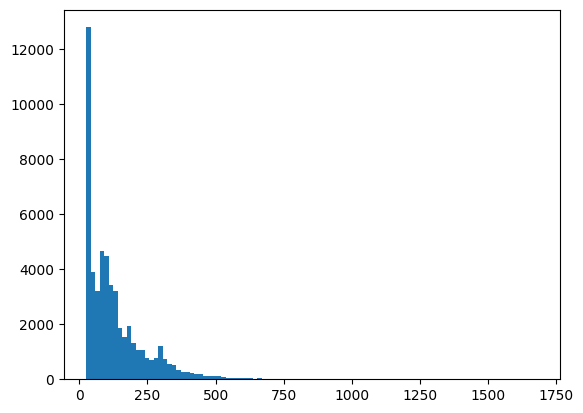

In [6]:
# plot a histogram of the domain_length column
import matplotlib.pyplot as plt

plt.hist(df_metrics['domain_length'], bins=100)
plt.show()



In [ ]:
# Save df_metrics to a csv file with _metrics suffix
dpam_info_metrics_csv = os.path.join(os.path.dirname(dpam_info_csv), os.path.basename(dpam_info_csv).replace('.csv', '_metrics.csv'))
df_metrics.to_csv(dpam_info_metrics_csv, index=False)


___
### Review linker sequences that handle_gaps.py created

`handle_gaps.py` is used to bridge the gap in sequence if DPAM-AI creates a domain split with gaps:
- If gap_length <20: fill with UniProt sequence
- If gap_length >20, check:
    - If randomly generated linker is shorter than 50% of the endogenous loop sequence: replace with randomly generated flexible linker sequence.
    - If randomly generated linker is more than 50% of the endogenous loop sequence: use endogenous sequence (if it doesn't save that much length, might as well use UniProt sequence)

Currently, `handle_gaps.py` creates random flexible linker sequences using the following parameters:
- `s_percent`: Percentage of S between 0.2 and 0.4
- `ds_ratio`: randomly mutate S to D with a probability between 0.1 and 0.3
- `max_consecutive_g`: maximum number of consecutive G is 4
- `max_consecutive_s`: maximum number of consecutive S is 2

These linkers are used to generate the sequences in the column `domain_seq` - the sequence that should be used for ordering synthetic DNA construct to recapitulate the folded domain but replacing long disordered region in the endogenous sequence with GS(D) linker. 

In [11]:
# Collect all non-empty linker sequences into a flat list
linker_seqs_raw = df_metrics['linker_seqs'].dropna()

# Flatten the list so every sequence, split on ',', becomes its own element
flat_linker_seqs = []
for item in linker_seqs_raw:
    if ',' in item:
        flat_linker_seqs.extend([seq for seq in item.split(',') if seq != ''])
    else:
        if item != '':
            flat_linker_seqs.append(item)

# Remove items in the list that contains characters other than G, S, D 
# and print the list
linker_seqs_clean = [seq for seq in flat_linker_seqs if all(c in 'GSD' for c in seq)]
print(linker_seqs_clean)


['GGGDGGSGGSSGG', 'GGGSGG', 'GSSGGGGG', 'GGGSGG', 'GGGGSSGGGDGGGGSGGGGSSGGGSGGSGGGGDGGSGGGG', 'GGSSGGGGSGGSDGGGGSGGGGSGGGGSGGGGSGG', 'GGG', 'GGGSGG', 'GGGSSGGSG', 'GGGSSGG', 'GSG', 'GGSG', 'GGSGSGGG', 'GGGGSG', 'GGSSGG', 'GGSGG', 'GGSG', 'GGGGSG', 'GGGSGGSSGGGGDGGG', 'GGG', 'GGGGSGG', 'GGSG', 'GGGGSGSGG', 'GGSGGGGG', 'GGSGGSGSSGGG', 'GGSGSGGGG', 'GGGGSGGG', 'GSGGSDGGGGSGGG', 'GGSSGSGG', 'GSSGG', 'GGG', 'GGGGSGSDG', 'GSG', 'GSGG', 'GGSGGG', 'GGGSSGGGGG', 'GSGGG', 'GGGGG', 'GSGGGGSGG', 'GGGSSGSG', 'GGGSSGSGG', 'GSSGGG', 'GGSDGGGGSGSGGSGSGSGG', 'GGGSG', 'GGSGGGGDGGGSGGG', 'GGGGSGGGGSSGGSSGGDSGGGGDGG', 'GGSGG', 'GGSSGGSSGG', 'GGSG', 'GGGGSG', 'GGSG', 'GGGGSGSGG', 'GGGSSGGG', 'GGG', 'GSG', 'GGSGG', 'GGGGSSGG', 'GSGGGGSGGGGSGGGDGG', 'GGGSSGGSGGG', 'GGSGGG', 'GGSG', 'GSDGGGSG', 'GGGGSG', 'GGGGSGSGGGSGG', 'GGGGSSG', 'GGGGSGGGGSGGGGG', 'GGGGDGGSGSGG', 'GGSGG', 'GGGSGGGG', 'GGGGG', 'GSG', 'GSGG', 'GGGSGG', 'GGGGG', 'GSSGGGG', 'GSGGGSGGGG', 'GGGGSG', 'GSGSGGGDSGGG', 'GSGSGGG', 'GSSGSSGGGGDG', 'GG

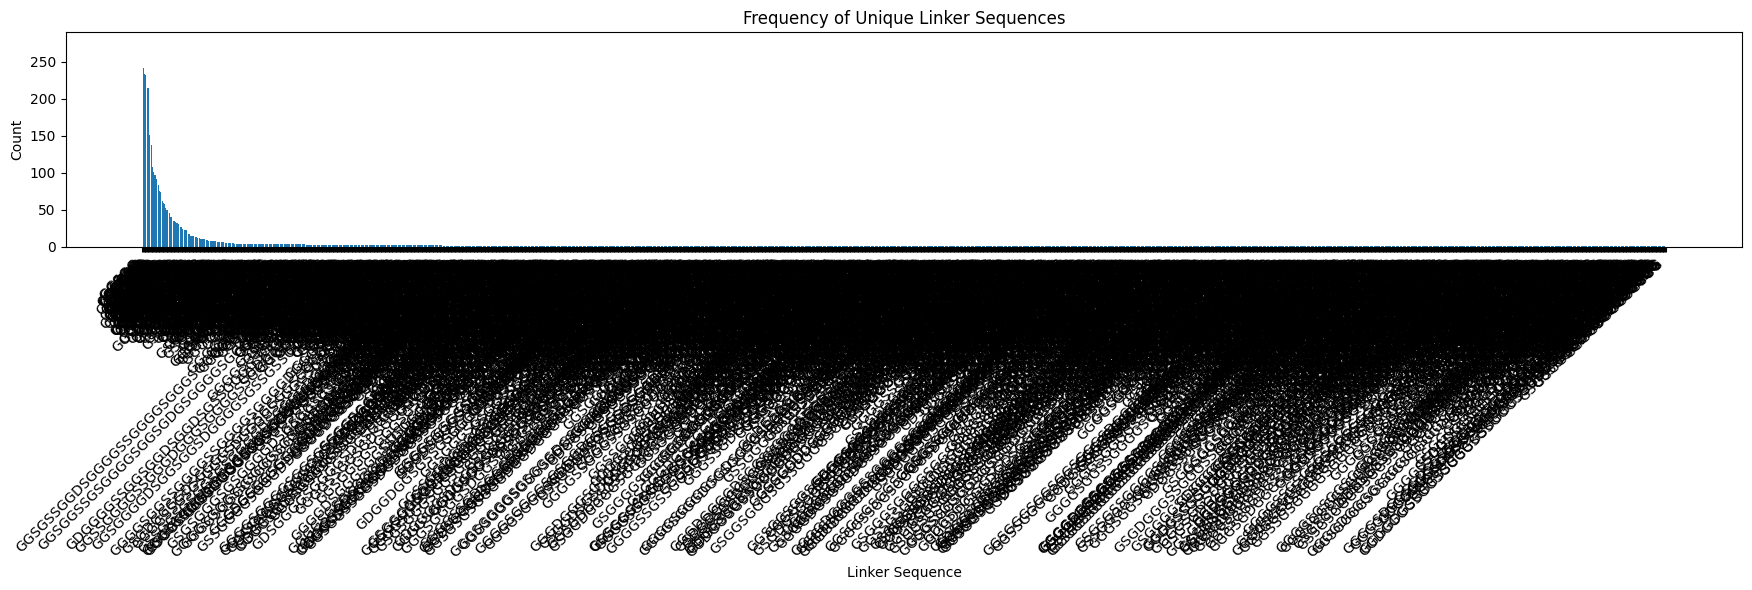

In [14]:
# Count the number of each unique linker sequence, sort them from most to least frequent, and plot as a bar chart with rotated x-axis labels

import matplotlib.pyplot as plt
from collections import Counter

linker_seqs_counts = Counter(linker_seqs_clean)
# Sort sequences from most to least frequent
sorted_items = sorted(linker_seqs_counts.items(), key=lambda x: x[1], reverse=True)
sequences, counts = zip(*sorted_items) if sorted_items else ([], [])
plt.figure(figsize=(18, 6))  # Make the plot wider
plt.bar(sequences, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Linker Sequence')
plt.ylabel('Count')
plt.title('Frequency of Unique Linker Sequences')
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Top 100 Linker Sequences')

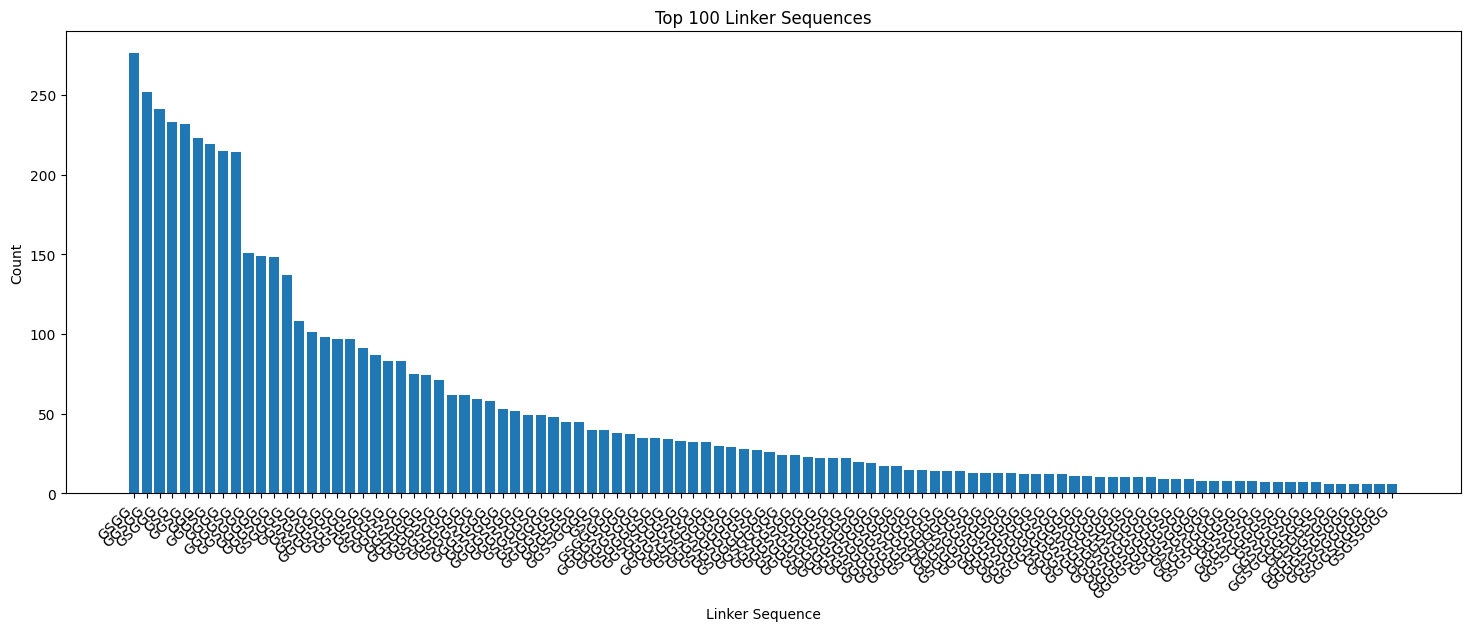

In [15]:
# Plot the top 100 linker sequences
plt.figure(figsize=(18, 6))
plt.bar(sequences[:100], counts[:100])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Linker Sequence')
plt.ylabel('Count')
plt.title('Top 100 Linker Sequences')

Text(0, 0.5, 'Count')

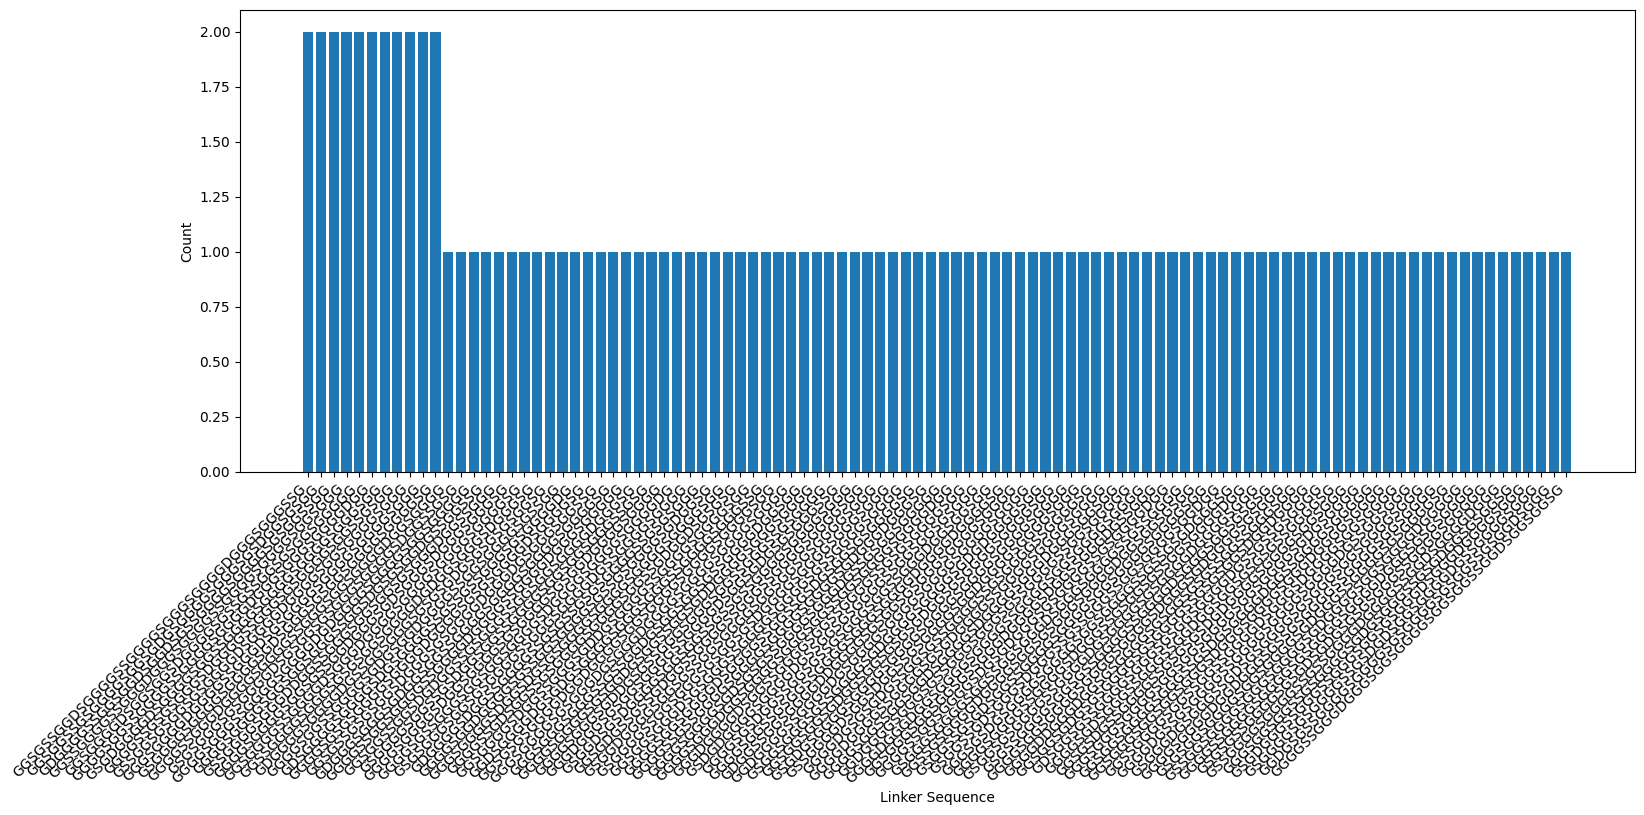

In [19]:
# Sort the sequences by character count, from most to least, and sort counts to match
sorted_seq_count_pairs = sorted(zip(sequences, counts), key=lambda x: len(x[0]), reverse=True)
sorted_sequences, sorted_counts = zip(*sorted_seq_count_pairs) if sorted_seq_count_pairs else ([], [])
plt.figure(figsize=(18, 6))
plt.bar(sorted_sequences[:100], sorted_counts[:100])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Linker Sequence')
plt.ylabel('Count')

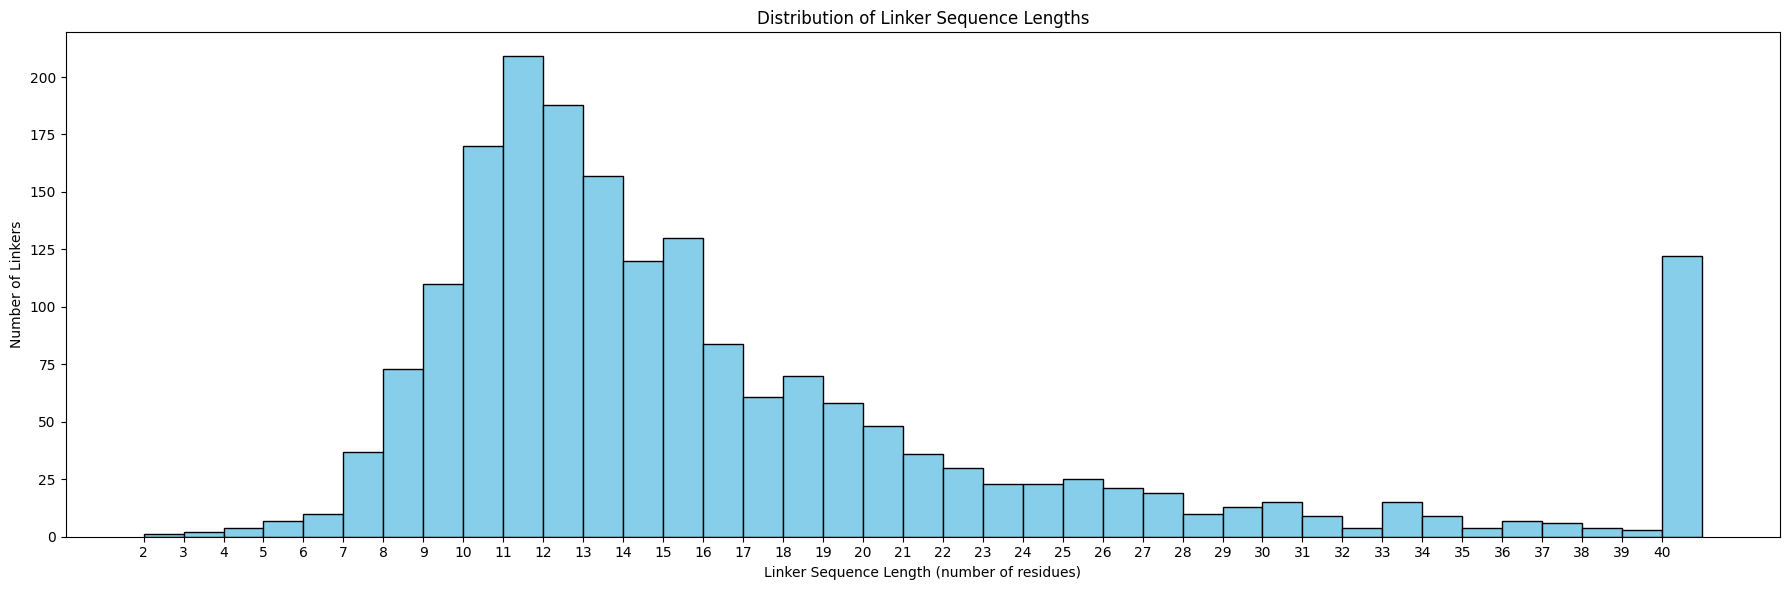

In [24]:
# Plot a histogram of the character count of sequences
plt.figure(figsize=(18, 6))
linker_lengths = [len(seq) for seq in sequences]
plt.hist(linker_lengths, bins=range(min(linker_lengths), max(linker_lengths) + 2), color='skyblue', edgecolor='black')
plt.xlabel('Linker Sequence Length (number of residues)')
plt.ylabel('Number of Linkers')
plt.title('Distribution of Linker Sequence Lengths')
plt.xticks(range(min(linker_lengths), max(linker_lengths) + 1))
plt.tight_layout()
plt.show()

___
### Bug fix: unnecessary terminal ACE/NME (WIP)

The `scripts/python/add_caps.py` in commit `ac315c8cb7dd01d4b27e5d2d3ccc748a995abdb5` contains a bug where it adds ACE and NME to all the termini of all domain models. 

It should not have added NME before residue 1, or add NME after the last residue. 

In [ ]:
# add a new column to check if the domain contains terminal residues:

from typing import Tuple
import re
def _parse_range_fragment(frag: str) -> Tuple[int, int]:
    """
    Parse a range fragment like '65-99' or '-205--176' into (start, end).
    Handles both positive and negative residue indices.
    """
    match = re.match(r"^(-?\d+)-(-?\d+)$", frag.strip())
    if not match:
        raise ValueError(f"Invalid range fragment: {frag!r}")
    return int(match.group(1)), int(match.group(2))


def range_contains_terminus(range_str, full_sequence):

    # Split range string by ',', space, or '-'
    fragments = re.split(r'[,]', range_str)
    
    first_fragment = fragments[0]
    last_fragment = fragments[-1]
    
    first_start, first_end = _parse_range_fragment(first_fragment)
    last_start, last_end = _parse_range_fragment(last_fragment)

    if first_start == 1 or last_end == len(full_sequence):
        return True
    
    return False
    

# Apply the function to the df_metrics dataframe
df_metrics['contains_terminus'] = df_metrics['Range'].apply(lambda x: range_contains_terminus(x, df_metrics['full_sequence']))
df_metrics['length'] = df_metrics['full_sequence'].apply(len)

# Display the dataframe where contains_terminus is True
df_contains_terminus = df_metrics[df_metrics['contains_terminus']]

df_contains_terminus.to_csv('DPAM-AI_AFDB_domainome_v6/contains_terminus.csv', index=False)